# Exercise Notebook: Exploring Text Embeddings and Information Retrieval

## Objective:
In this exercise, we will:
1. Review the concept of text embeddings.
2. Implement three information retrieval techniques: TF-IDF, BM25, and Sentence Transformers.
3. Visualize the results of these models in 2D and compare their performance for movie recommendation based on title and overview.

### 1. Review of Text Embeddings

#### What are Embeddings?
Embeddings are dense vector representations of text that capture semantic information. Rather than representing words or documents as **sparse one-hot vectors**, embeddings map them to continuous vector spaces where semantically similar items are closer together.

There are different techniques to generate embeddings:
- **TF-IDF**: Statistical method that reflects how important a word is to a document in a collection.
- **BM25**: A probabilistic model that improves upon TF-IDF by considering term frequency saturation and document length.
- **Sentence Transformers**: Use deep learning models to generate embeddings for sentences or documents that reflect semantic meaning.


Relevant: [one-hot encoding](https://developers.google.com/machine-learning/crash-course/categorical-data/one-hot-encoding)

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Utilizador\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7


### 2. Dataset
We will use the [Movies Dataset from Kaggle](https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset) to create a simple movie recommendation system based on titles and overviews.

The dataset includes:
- **title**: Name of the movie
- **overview**: A brief description of the movie

#### Task 1: Load the dataset
Download the dataset and load it into a Pandas DataFrame.


In [17]:
import pandas as pd

# Load dataset
df = pd.read_csv('./data/movies_metadata.csv')

# Keep only the 'title' and 'overview' columns
df = df[['title', 'overview']]

# Display first few rows
df.head()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_12176\2377670287.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/movies_metadata.csv')


,title,overview
0,Toy Story,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...


### Task 1.1 Explore data
Check for missing data, title and overview length distribution and perform a word cloud visualization

In [18]:
def missing_statistics(df):
  return df[df["title"].isnull() | df["overview"].isnull()]

missing_statistics(df)

,title,overview
32,Wings of Courage,NaN
300,Roommates,NaN
634,Peanuts – Die Bank zahlt alles,NaN
635,Happy Weekend,NaN
641,The Superwife,NaN
...,...,...
45342,Over/Under,NaN
45377,Simbad e il califfo di Bagdad,NaN
45398,Thick Lashes of Lauri Mäntyvaara,NaN
45399,All at Once,NaN


In [19]:
def compute_title_distribution(df: pd.DataFrame):
  title_dist = df["title"].apply(lambda x: len(str(x)))
#   return title_dist.plot()

compute_title_distribution(df)

In [20]:
def compute_overview_distribution(df: pd.DataFrame):
    title_dist = df["overview"].fillna("").apply(lambda x: len(str(x)))
    # return title_dist.plot(kind="line")


compute_overview_distribution(df)

In [21]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download("stopwords")
from nltk.stem import SnowballStemmer, WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

nltk.download("wordnet")




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Utilizador\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Utilizador\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [22]:
def standardize_data(sentence, stopwords = stopwords.words("english")):
    
    sentence = sentence.lower()
    words = word_tokenize(sentence)
    new_words = [word for word in words if not word in stopwords]
    lemmatized_words = [lemmatizer.lemmatize(word.lower(), pos="v") for word in new_words]
    
    
    return ' '.join(lemmatized_words) 

import matplotlib.pyplot as plt
from wordcloud import WordCloud

def world_cloud(df: pd.DataFrame):
	df["overview"] = df["overview"].fillna("")

	df["std_overview"] = df["overview"].apply(lambda x: standardize_data(x))

	corpus = df["std_overview"].str.cat(sep = " ")
	a_long_sentence = standardize_data(corpus)
	wc = WordCloud(background_color='white', max_words=70)#,colormap='gist_gray')                  # Customize the output.
	wc.generate(a_long_sentence)
	# wc.words_                                                          # Check for the top ranking words.                                                         
	plt.figure(figsize=(10,10))
	plt.imshow(wc, interpolation='bilinear')
	plt.axis("off")                                    # Turn off the axes.
	plt.show()
 

# world_cloud(df)

### 3. Data Preprocessing
Before we move on to the information retrieval methods, we'll preprocess the data by cleaning the text and performing tokenization. This will help ensure better results from our algorithms.

#### Task 2: Clean the text
Write a function to clean the text by removing punctuation, converting it to lowercase, and removing digits.

In [23]:
import re
import string


def clean_text(text):
    text = text.lower()
    punctuation = re.escape(string.punctuation)
    text = re.sub(rf"[\d{punctuation}]", "", text)
    return text.strip()

clean_text("Hello, World!23 2 3")

'hello world'

In [24]:
from sklearn.model_selection import train_test_split


# Apply cleaning function to 'overview' and 'title' columns
df['overview'] = df['overview'].astype(str).apply(clean_text)
df['title'] = df['title'].astype(str).apply(clean_text)

# Split data into train and test for evaluation
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)
#In this notebook we will not be doing evaluation yet, feel free to use all data.

# Display a cleaned sample
df.head()

,title,overview
0,toy story,led by woody andys toys live happily in his ro...
1,jumanji,when siblings judy and peter discover an encha...
2,grumpier old men,a family wedding reignites the ancient feud be...
3,waiting to exhale,cheated on mistreated and stepped on the women...
4,father of the bride part ii,just when george banks has recovered from his ...


### 4. TF-IDF Approach
#### Task 3: Apply TF-IDF Vectorization
Use `TfidfVectorizer` to transform the 'overview' text data into a TF-IDF matrix. Compute the cosine similarity between the movie overviews.

Relevant: [TfidfVectorizer](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Fit and transform the overview data
tfidf_vectorizer = TfidfVectorizer(max_features=100000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["overview"][:1000])

In [69]:
# Compute the cosine similarity matrix
cos_sim_tfidf = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Function to get top 5 similar movies based on cosine similarity
def get_similar_movies(index, cos_sim_matrix, top_n=5):
    similar_indices = cos_sim_matrix[index].argsort()[-top_n-1:-1][::-1]
    return train_data.iloc[similar_indices][['title', 'overview']]

# Example: Get similar movies for the first movie
get_similar_movies(0, cos_sim_tfidf)

,title,overview
11187,cabin in the sky,chronic gambler and carouser little joe jackso...
25637,the haunting of helena,after a divorce sophia moves to the south of i...
5646,ghost ship,after discovering a passenger ship missing sin...
35498,the condemned of altona,a dying german magnate invites his youngest so...
35413,tomorrows joe,set in the s joe yabuki tomohisa yamashita liv...


In [28]:
df["overview"][31786]

'the story of a journalist in southern germany who stays with a novelist and his wife and gradually begins to destroy the young couples lives'

In [29]:
df["overview"][11187]

'chronic gambler and carouser little joe jackson is shot by domino johnson at jim henrys gambling club over an outstanding gambling debt little joes wife the godfearing petunia jackson prays not only for her husbands mortal life but also his eternal soul as shes afraid that if he dies now he despite not being an evil man wont make it into heaven as little joe is close to death he is visited by agents of both the lord and of lucifer they make a deal with him they will give him six months to atone for the errors of his human life once back on earth he wont remember the deal but both the lord and lucifer will be watching over him trying to get him to see things their way as both sides try to get little joes soul they figure that some of the most powerful tools they have at their disposal are the women in little joes life petunia on behalf of the lord and georgia brown a golddigging floozy on behalf of lucifer'

### 5. BM25 Approach
#### Task 4: Apply BM25 (bonus)
Use the `rank_bm25` library to compute BM25 scores for the overviews of the movies.

```python
from rank_bm25 import BM25Okapi
```

Relevant: [rank_bm25](https://pypi.org/project/rank-bm25/)

In [64]:
from rank_bm25 import BM25Okapi

# Fill missing values in the "overview" column
df["overview"] = df["overview"].fillna("")

# Standardize the "overview" text (remove stopwords, punctuation, etc.)
df["std_overview"] = df["overview"].apply(lambda x: standardize_data(x))

# Tokenize each document in the corpus (split on space)
tokenized_corpus = df["std_overview"].apply(lambda x: x.split(" "))

# Initialize BM25Okapi with the tokenized corpus
bm25 = BM25Okapi(tokenized_corpus)

# Query to search for similar documents
query = "lead, woody, toy, judy, peter, small town"
tokenized_query = query.split(" ")

# Get the scores for each document in the corpus based on the query
doc_scores = bm25.get_scores(tokenized_query)

# Print the document scores
print(doc_scores)




[0.         0.         0.         ... 0.         4.36697622 0.        ]


### 6. Sentence Transformers Approach
#### Task 5: Apply Sentence Transformers
Use the `sentence-transformers` library to generate dense embeddings for the titles and overviews. Then compute cosine similarity between the embeddings.

Relevant: [sentence-transformers](https://sbert.net/)


In [1]:
from sentence_transformers import SentenceTransformer

# Initialize pre-trained model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Generate embeddings for titles and overviews
embeddings = model.encode(df["title"][:3000].astype(str) + " " + df["overview"][:3000].astype(str), show_progress_bar=True)


C:\Users\Utilizador\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [71]:
def compute_cosine_similarity(embeddings, index):
    cosine_sim = cosine_similarity([embeddings[index]], embeddings)
    return cosine_sim[0]

# Get top 5 similar movies based on sentence embeddings
cos_sim_sentence = compute_cosine_similarity(embeddings, 0)
top_sentence_indices = cos_sim_sentence.argsort()[-6:-1][::-1]
train_data.iloc[top_sentence_indices][['title', 'overview']]



,title,overview
11187,cabin in the sky,chronic gambler and carouser little joe jackso...
24534,the hit list,a disgruntled man creates a hit list with a st...
25296,slasher house,when red awakens in a prison cell within an ol...
9188,cut,a group of film students set out to finish fil...
35166,ostia,nan


### 7. Visualization of Embeddings in 2D
We will now visualize the embeddings of the three methods (TF-IDF, BM25, and Sentence Transformers) in 2D space using **t-SNE**. This will help us understand which method captures the best semantic relationships.

#### Task 6: Visualize the embeddings
Use t-SNE to reduce the dimensionality of the embeddings and plot them in 2D.

Relevant: [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
[PCA](https://scikit-learn.org/dev/modules/generated/sklearn.decomposition.PCA.html)

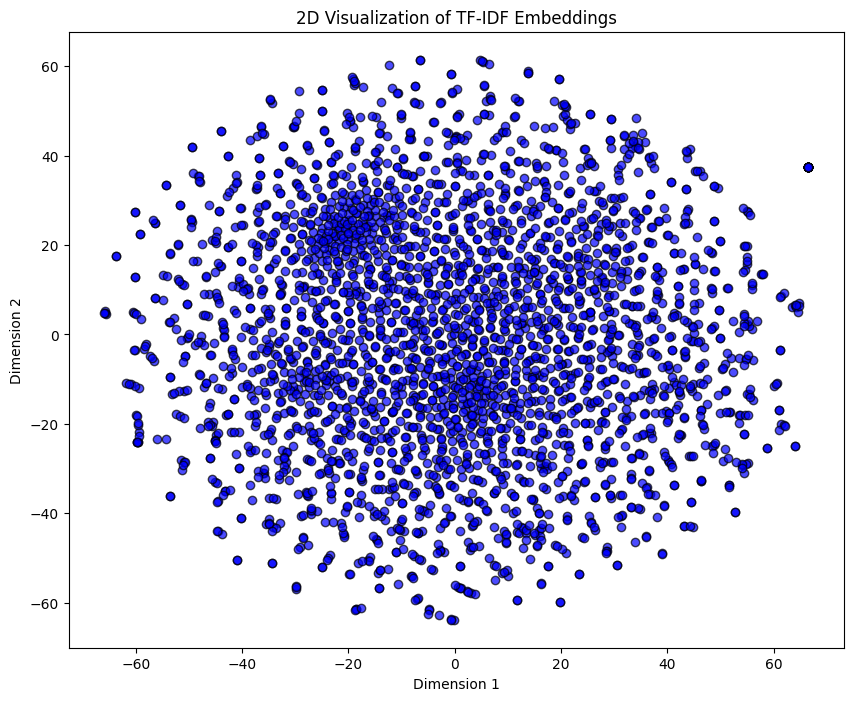

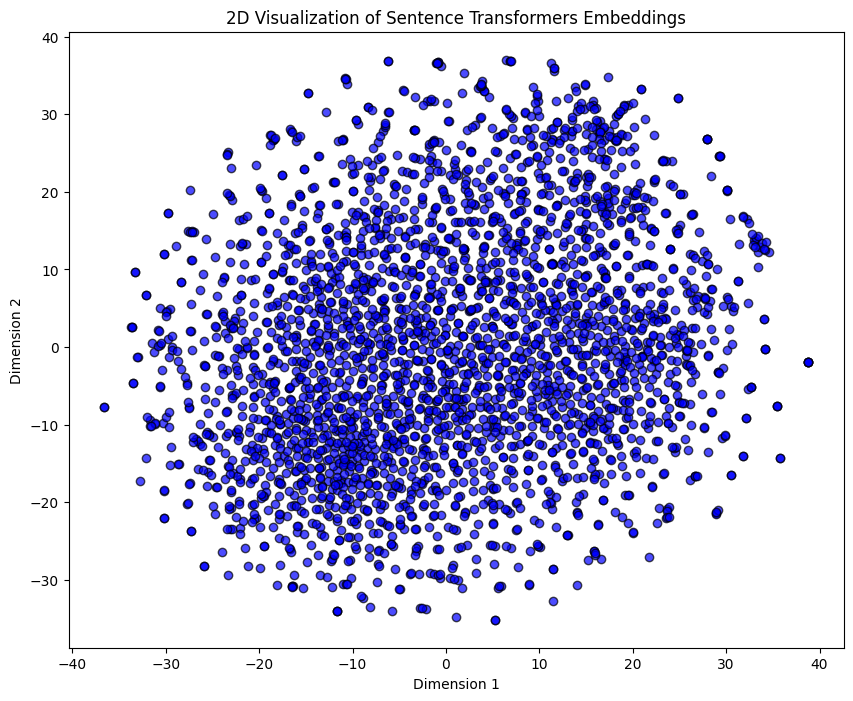

In [72]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reduce the dimensionality of the embeddings for visualization
def plot_embeddings(embeddings, title):
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c='blue', edgecolors='k', alpha=0.7)
    plt.title(f'2D Visualization of {title} Embeddings')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()

# TF-IDF Visualization
plot_embeddings(tfidf_matrix.toarray(), 'TF-IDF')

# Sentence Transformer Visualization
plot_embeddings(embeddings, 'Sentence Transformers')

### Task 6.1
You showed the plots you just did above to your boss but he is finding it hard to understand if the embeddings are capturing any meaningfull value.
What do you do?

In [ ]:
#TODO
#maybe look at the rest of the data and try to put better labels on the plot so its easier to understand ?

### 8. Discussion and Comparison
#### Questions for the students to reflect on:
- **Why do we clean the data?**
- **Do we always need to clean the data?**
- **What is the conceptual difference between syntatic and semantic embeddings?**
- **Which embedding method appears to capture the best semantic relationships between movies?**
- **Do the 2D visualizations show any clear clusters or patterns?**
- **How do the different algorithms perform when compared in terms of recommendation accuracy?**
- **Can the additional metadata (e.g., genres, actors) improve the system? If so, how?**

### 9. Extension Ideas
- **Improve with additional metadata**: You can integrate other columns like 'genres', 'cast', or 'director' to generate richer embeddings.
- **Evaluation**: Perform precision and recall evaluation on your retrieval methods by comparing the top recommendations against a manually curated set of similar movies - we will be doing this in a future exercise today.
- **Model Fine-Tuning**: Fine-tune a Sentence-Transformer model on your dataset to improve the embeddings.